josep
Medulla2026
localhost
glp1_analytics


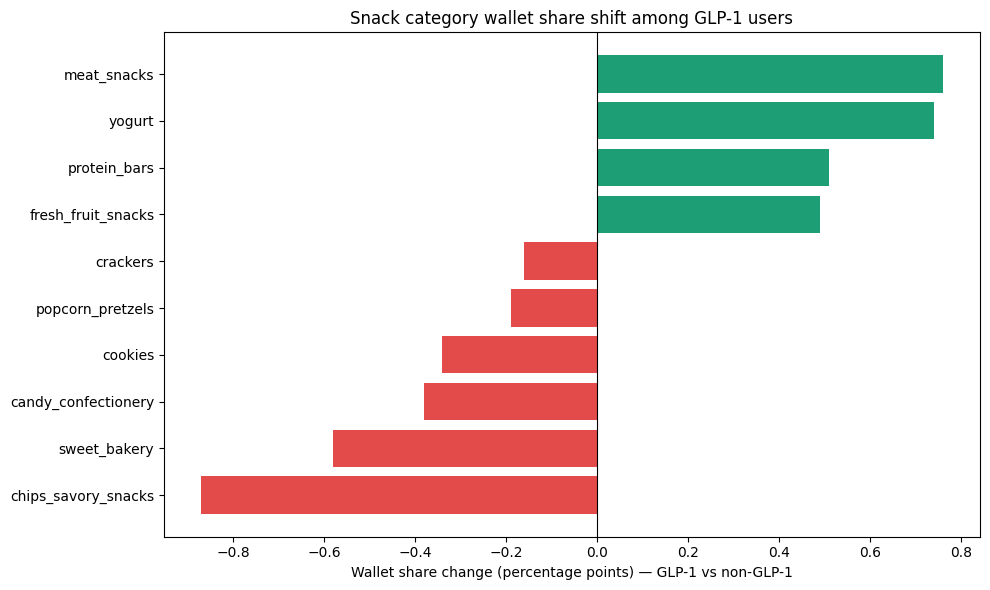

In [ ]:
 ngine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}"
)
# Load the wallet share query result
wallet_share = pd.read_sql("""WITH total_spend AS (
    SELECT household_id, month,
           SUM(spend) AS total_snack_spend
    FROM transactions
    GROUP BY household_id, month
),
category_spend AS (
    SELECT t.household_id, t.month, c.category_name, t.spend
    FROM transactions t
    JOIN categories c ON t.category_id = c.category_id
)
SELECT
    cs.category_name,
    h.is_glp1_user,
    ROUND(AVG(cs.spend / NULLIF(ts.total_snack_spend, 0) * 100)::NUMERIC, 2) AS avg_wallet_share_pct,
    -- Window function: rank categories by wallet share within each GLP-1 group
    RANK() OVER (
        PARTITION BY h.is_glp1_user
        ORDER BY AVG(cs.spend / NULLIF(ts.total_snack_spend, 0)) DESC
    ) AS wallet_share_rank
FROM category_spend cs
JOIN total_spend   ts ON cs.household_id = ts.household_id AND cs.month = ts.month
JOIN households     h ON cs.household_id = h.household_id
GROUP BY cs.category_name, h.is_glp1_user
ORDER BY h.is_glp1_user DESC, avg_wallet_share_pct DESC""", engine)

# Pivot for visualization
pivot = wallet_share.pivot(index="category_name",
                            columns="is_glp1_user",
                            values="avg_wallet_share_pct")
pivot.columns = ["Non-GLP-1", "GLP-1 User"]
pivot["delta"] = pivot["GLP-1 User"] - pivot["Non-GLP-1"]
pivot_sorted = pivot.sort_values("delta")

# Diverging bar chart
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#E24B4A" if x < 0 else "#1D9E75" for x in pivot_sorted["delta"]]
ax.barh(pivot_sorted.index, pivot_sorted["delta"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Wallet share change (percentage points) — GLP-1 vs non-GLP-1")
ax.set_title("Snack category wallet share shift among GLP-1 users")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "dashboard" / "category_shift.png", dpi=150)
plt.show()